# Exploratory Data Analysis

## 1. Project Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for the project
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load Data
df = pd.read_csv("../data/raw/Loan_default.csv")

print("--- Dataset Overview ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n--- Missing Values ---")
print(df.isnull().sum().sum())
df.head()

--- Dataset Overview ---
Rows: 255347, Columns: 18

--- Missing Values ---
0


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## 2. Target Variable Analysis

Non-Default (0): 88.39%
Default (1): 11.61%


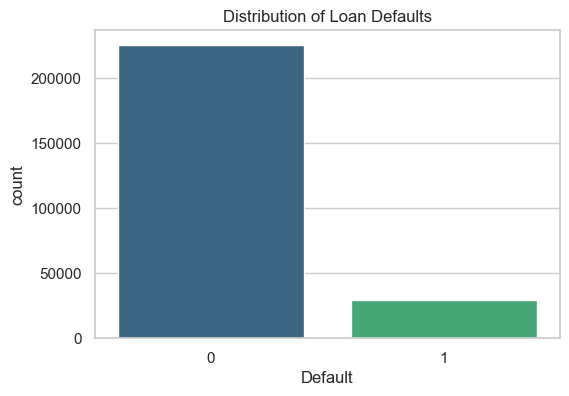

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Default', data=df, hue='Default', palette='viridis', legend=False)
plt.title('Distribution of Loan Defaults')

# Get exact percentages
counts = df['Default'].value_counts(normalize=True) * 100
print(f"Non-Default (0): {counts[0]:.2f}%")
print(f"Default (1): {counts[1]:.2f}%")
plt.show()

Before diving into features, we examine the target variable **'Default'**. 

> **Key Insight:** We see a significant class imbalance (approx 11% defaults). I will use F1-Score or Precision-Recall curves later to handle this.

## 3. Univariate Analysis: Numerical Distributions
We check the distribution of numerical features to identify skewness or the need for scaling.

--- Skewness in Numerical Features ---
Age               0.000698
Income           -0.000381
LoanAmount       -0.001827
CreditScore       0.004688
MonthsEmployed   -0.002142
NumCreditLines   -0.000278
InterestRate      0.004608
LoanTerm         -0.002178
DTIRatio         -0.001499
dtype: float64


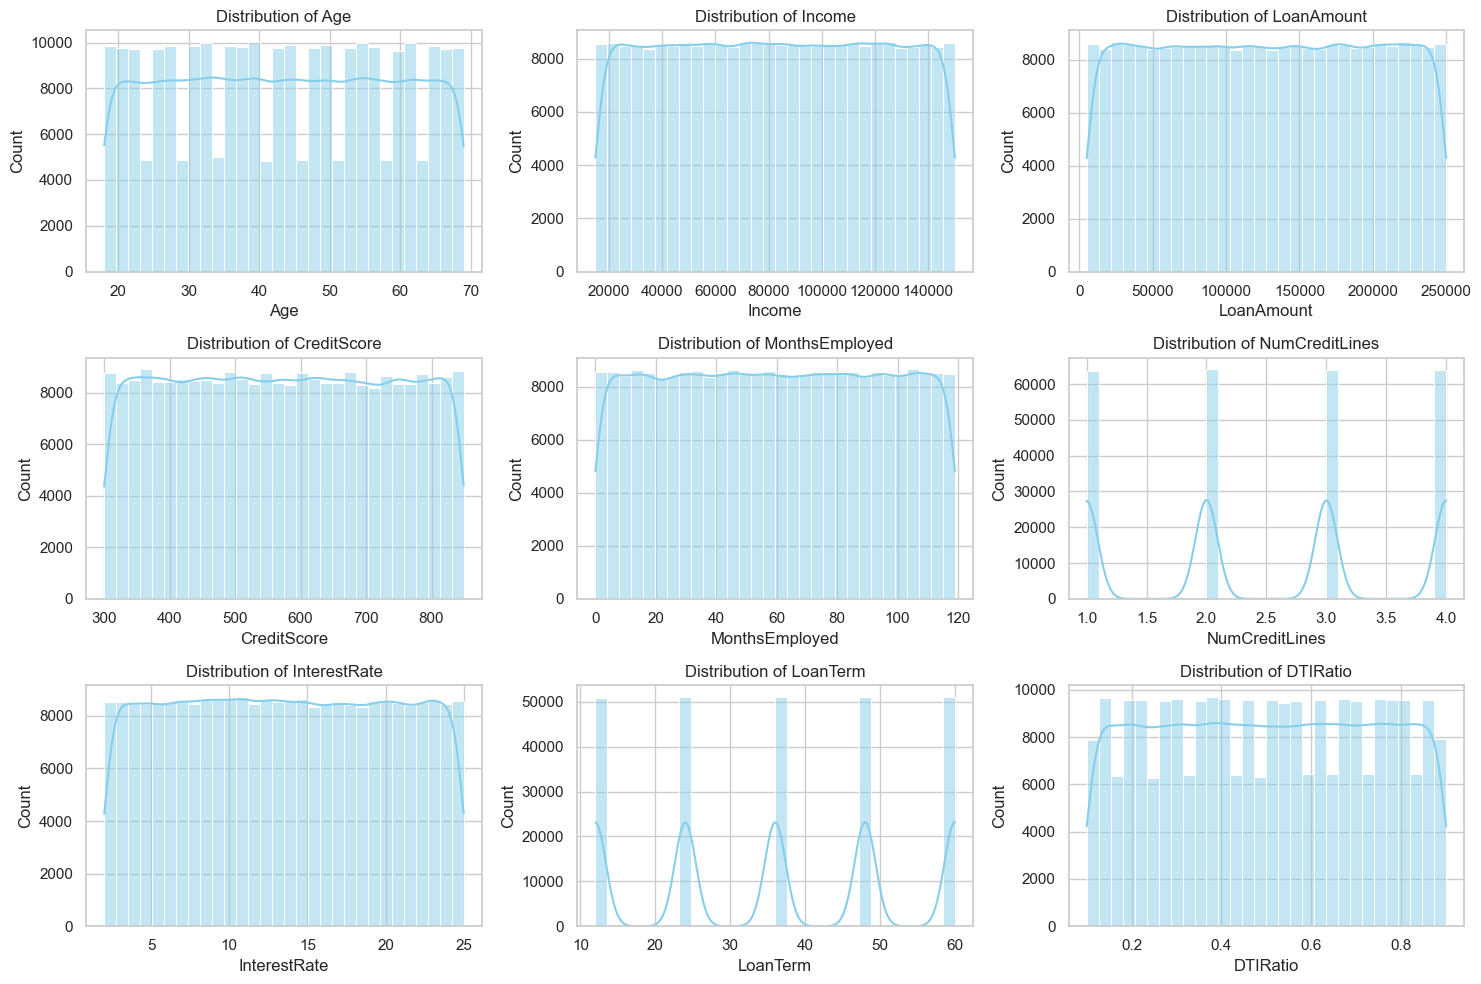

In [4]:
numeric_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

print("--- Skewness in Numerical Features ---")
print(df[numeric_cols].skew())

# Visualize distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## 4. Bivariate Analysis: Features vs. Default
Now we explore how individual features correlate with the likelihood of defaulting. Specifically, we look at age, income, and categorical risk levels.

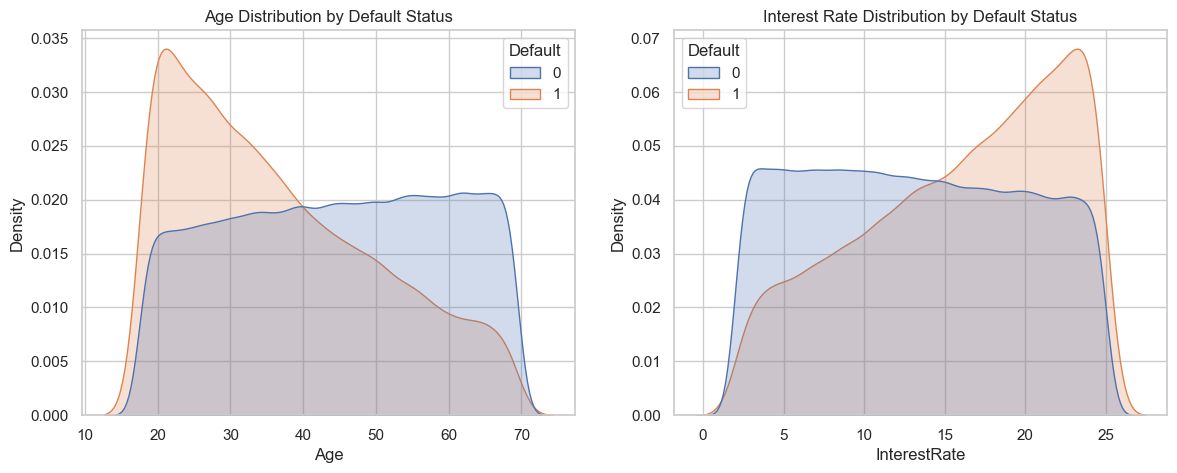

--- Default Risk by Education Level ---
Education
High School    0.128789
Bachelor's     0.121011
Master's       0.108717
PhD            0.105860
Name: Default, dtype: float64


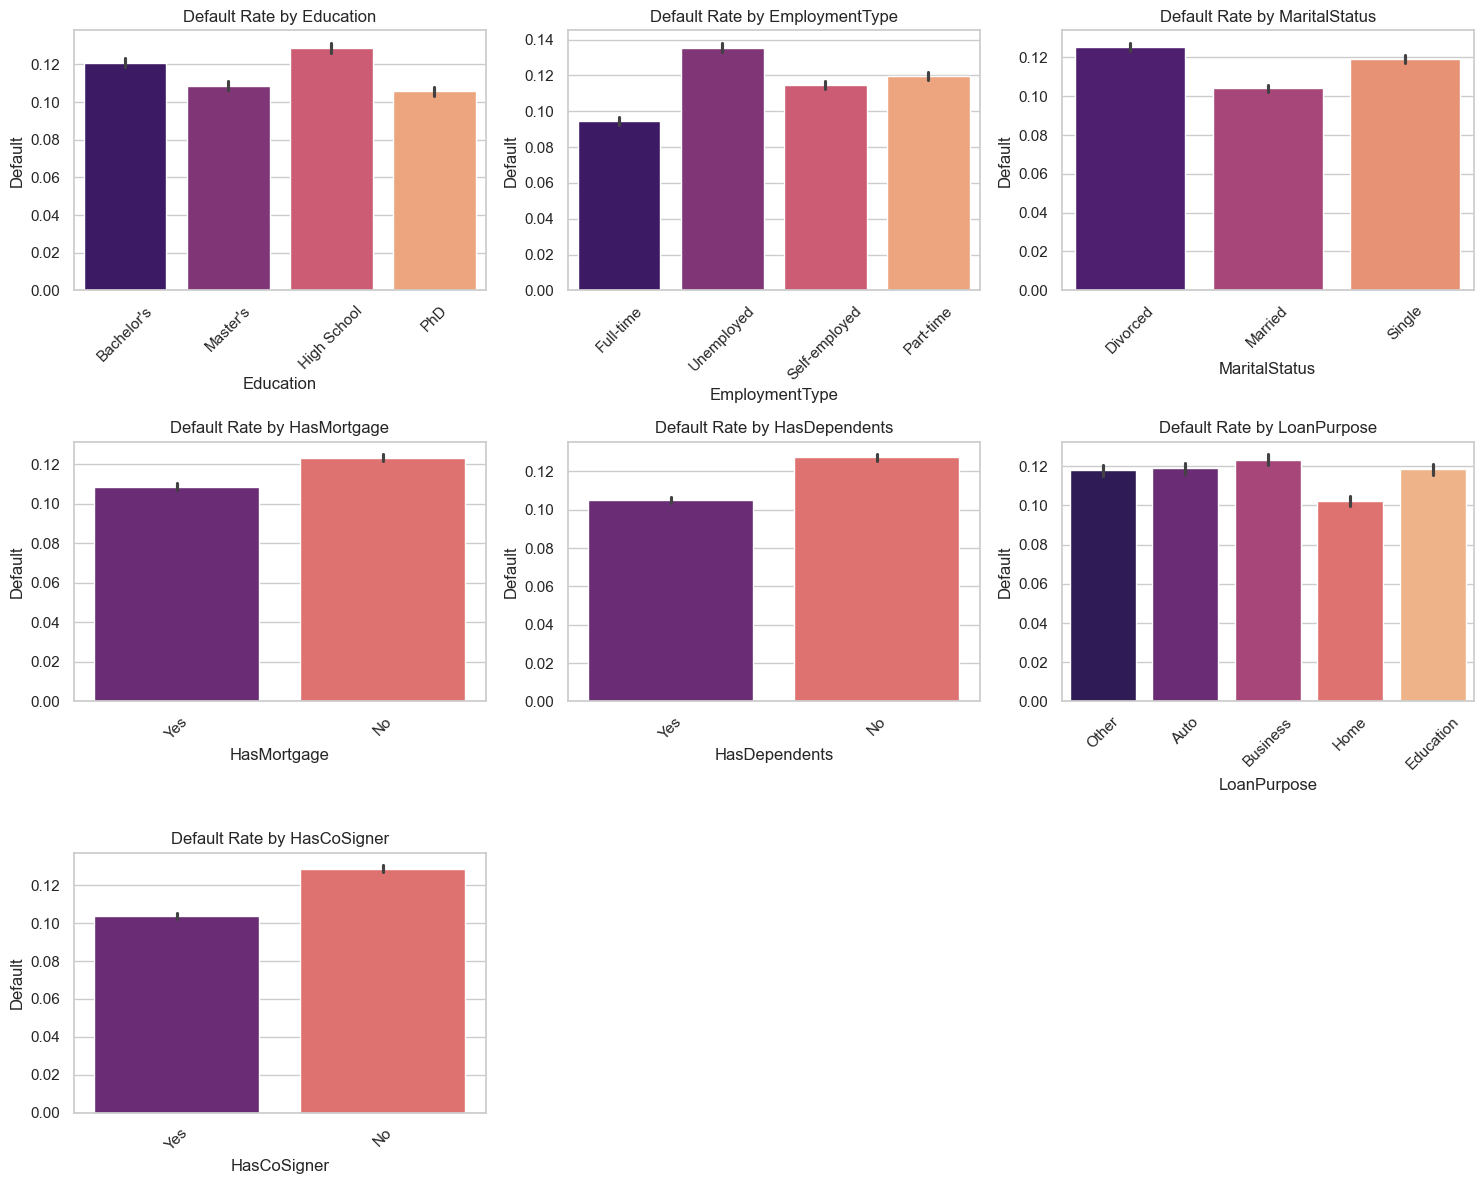

In [5]:
# 4.1 Numerical Relationships (KDE Plots)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='Age', hue='Default', fill=True, common_norm=False)
plt.title('Age Distribution by Default Status')

plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='InterestRate', hue='Default', fill=True, common_norm=False)
plt.title('Interest Rate Distribution by Default Status')
plt.show()

# 4.2 Categorical Risk (Example: Education)
education_risk = df.groupby('Education')['Default'].mean().sort_values(ascending=False)
print("--- Default Risk by Education Level ---")
print(education_risk)

# 4.3 General Categorical Analysis
cat_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

plt.figure(figsize=(15, 12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    sns.barplot(x=col, y='Default', hue=col,data=df, palette='magma')
    plt.title(f'Default Rate by {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Outlier Detection
Machine Learning models like Logistic Regression are sensitive to outliers. We use boxplots to check for extreme values.

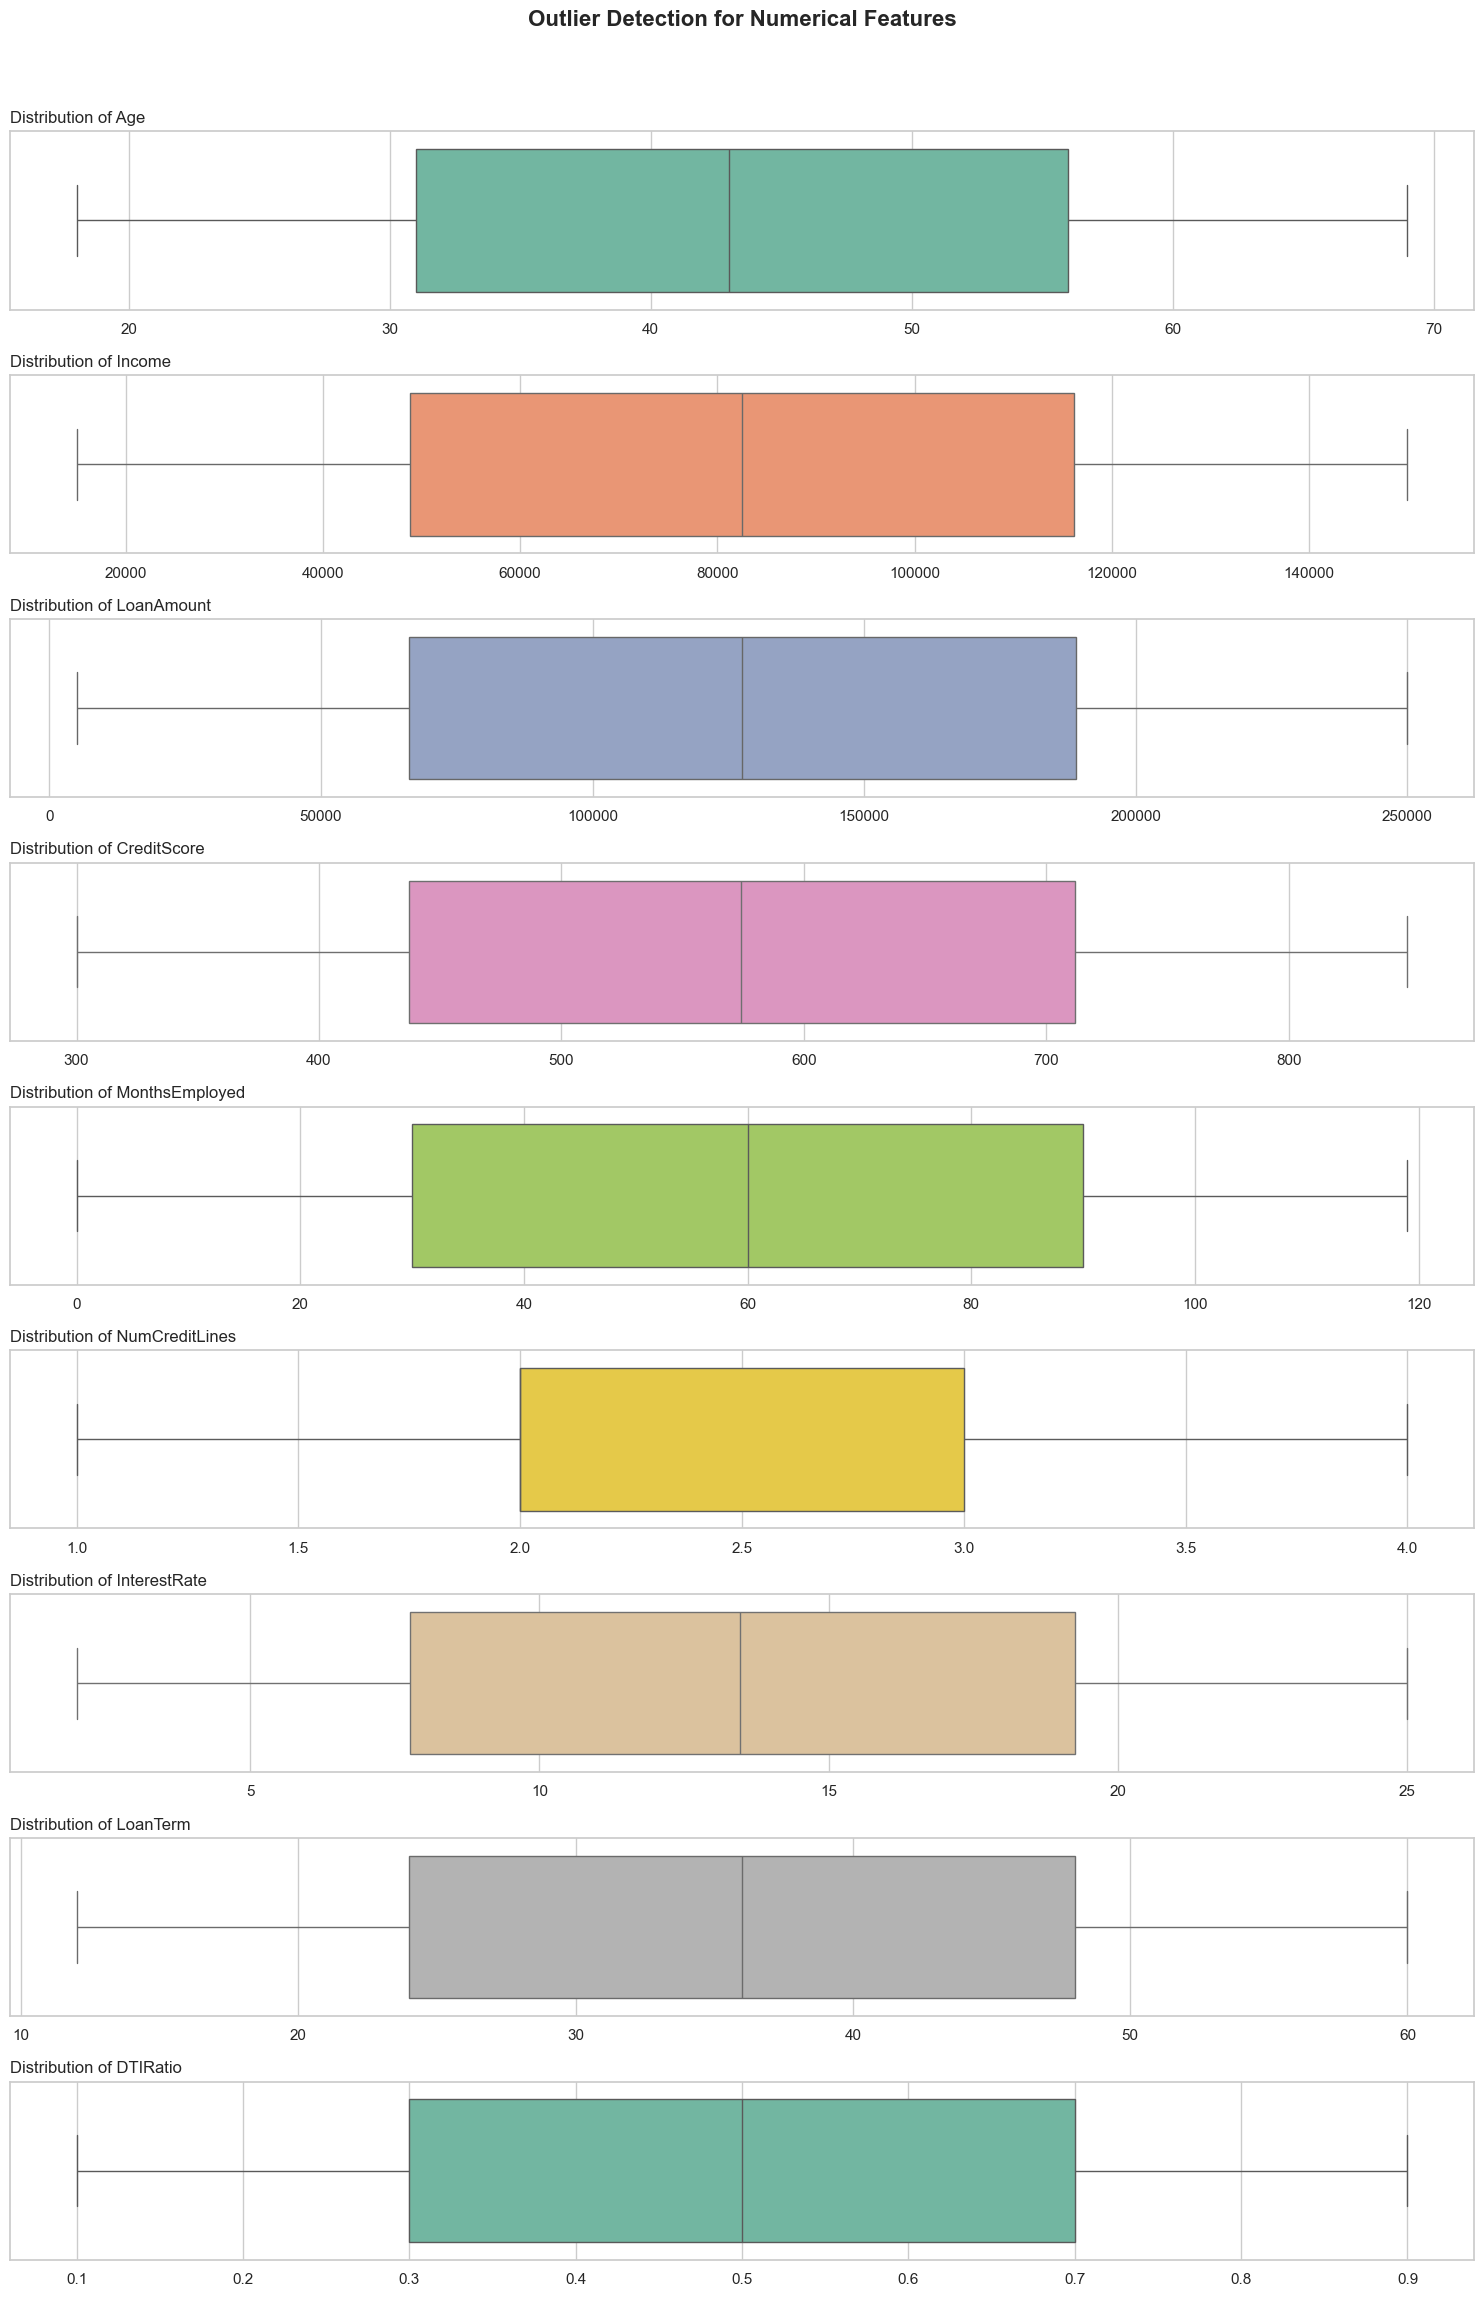

In [6]:
num_features = len(numeric_cols)
fig, axes = plt.subplots(
    nrows=num_features, ncols=1, figsize=(15, 2.5 * num_features), sharex=False
)
if num_features == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i],
        color=sns.color_palette("Set2")[i % len(sns.color_palette("Set2"))],
    )

    axes[i].set_title(f"Distribution of {col}", fontsize=12, loc="left")
    axes[i].set_xlabel("")
plt.suptitle(
    "Outlier Detection for Numerical Features", fontsize=16, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

# Insight: If boxplots show many points outside the whiskers, 
# we may need to apply RobustScaling or clipping.

## 6. Multivariate Analysis: Correlation Heatmap
We check for multi-collinearity (features that are too highly correlated with each other) and identify the strongest predictors.

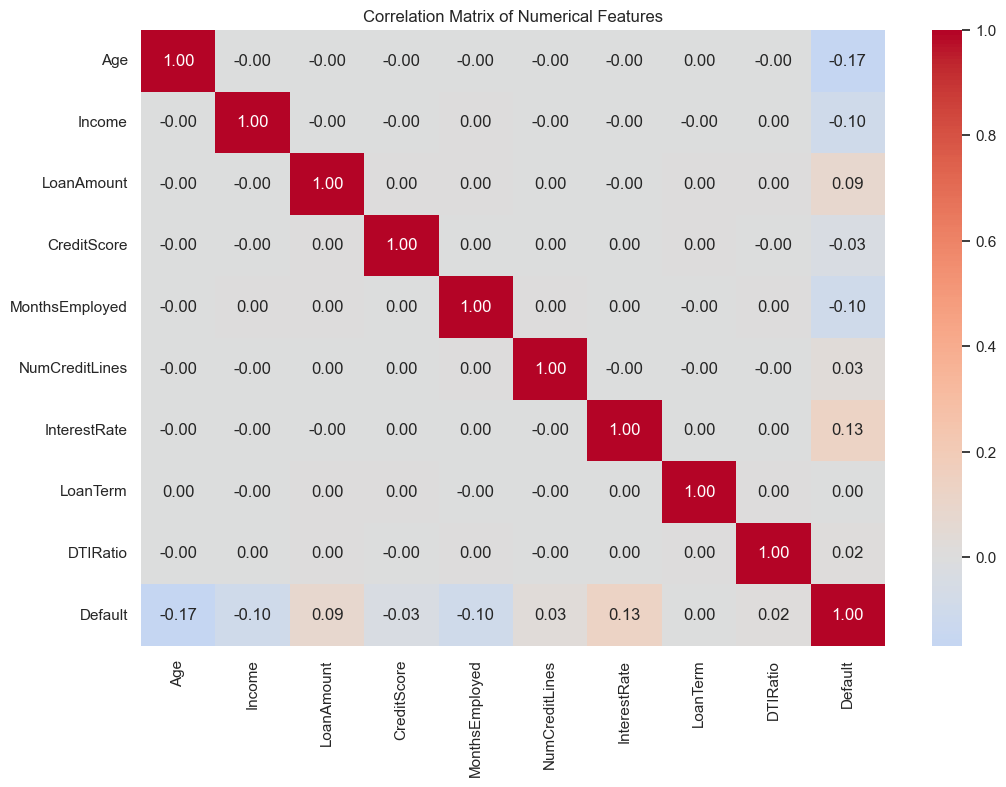

In [7]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## 7. Feature Engineering and Preprocessing
To prepare the data for ML, we drop unique identifiers, encode categorical variables into dummy variables (One-Hot Encoding), and filter for significant predictors.

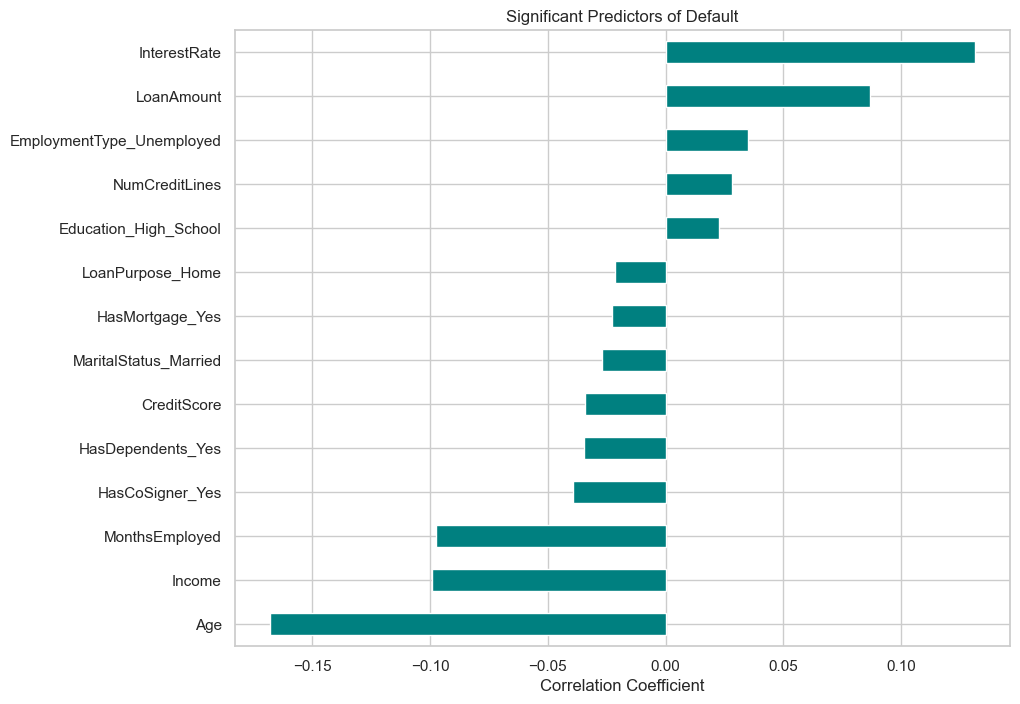

In [8]:
# 1. Drop non-predictive ID
df_analysis = df.drop(columns=['LoanID'], errors='ignore')

# 2. One-Hot Encoding (Avoiding Dummy Variable Trap with drop_first=True)
categorical_vars = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 
                    'HasDependents', 'LoanPurpose', 'HasCoSigner']

df_encoded = pd.get_dummies(df_analysis, columns=categorical_vars, drop_first=True, dtype=int)
# LightGBM rejects spaces in feature names (e.g. "Education_High School")
df_encoded.columns = df_encoded.columns.str.replace(r"[\s/]+", "_", regex=True)

# 3. Correlation with Target
all_corr = df_encoded.corr(numeric_only=True)['Default'].sort_values()

# Visualize significant predictors (> 0.02 absolute correlation), excluding the target itself
significant_corr = all_corr.drop('Default', errors='ignore')
significant_corr = significant_corr[abs(significant_corr) > 0.02]

plt.figure(figsize=(10, 8))
significant_corr.plot(kind='barh', color='teal')
plt.title('Significant Predictors of Default')
plt.xlabel('Correlation Coefficient')
plt.show()

# Machine Learning

## Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

# 1. Prepare Data
X = df_encoded.drop(columns=['Default'])
y = df_encoded['Default']

# 2. Split (tree models below do not require feature scaling)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

THRESHOLD = 0.3  # lower than 0.5 to boost recall (see threshold tuning cells)


## Baseline Models

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # handles imbalance for you
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.899     0.974     0.935     45139
           1      0.454     0.165     0.242      5931

    accuracy                          0.880     51070
   macro avg      0.676     0.569     0.588     51070
weighted avg      0.847     0.880     0.854     51070



In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_test)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.384   0.265   0.314   
0.3     0.454   0.165   0.242   
0.35    0.533   0.098   0.166   
0.4     0.607   0.055   0.100   
0.45    0.631   0.028   0.055   
0.5     0.694   0.013   0.025   


In [12]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Training timer
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

[LightGBM] [Info] Number of positive: 23722, number of negative: 180555
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1315
[LightGBM] [Info] Number of data points in the train set: 204277, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training time: 2.35 seconds
Prediction time: 0.1349 seconds
              precision    recall  f1-score   support

           0      0.965     0.400     0.566     45139
           1      0.163     0.890     0.276      5931

    accuracy                          0.457     51070
   macro avg      0.564     0.645     0.421     51070
weighted avg      0.872     0.457     0.532     51070



In [13]:
from sklearn.metrics import precision_score, recall_score, fbeta_score

proba = lgbm.predict_proba(X_test)[:, 1]

print("Threshold tuning for LightGBM")
print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F2_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f2 = fbeta_score(y_test, preds, beta=2, pos_label=1)
    print(f"{thresh:<8.2f}{prec:<8.3f}{rec:<8.3f}{f2:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F2_1    
0.25    0.149   0.925   0.454   
0.30    0.163   0.890   0.470   
0.35    0.178   0.843   0.482   
0.40    0.194   0.788   0.489   
0.45    0.213   0.730   0.491   
0.50    0.232   0.664   0.484   


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

Training time: 3.70 seconds
Prediction time: 0.0710 seconds
              precision    recall  f1-score   support

           0      0.962     0.420     0.585     45139
           1      0.165     0.873     0.278      5931

    accuracy                          0.473     51070
   macro avg      0.563     0.647     0.431     51070
weighted avg      0.869     0.473     0.549     51070



In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = xgb.predict_proba(X_test)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.151   0.911   0.259   
0.3     0.165   0.873   0.278   
0.35    0.181   0.825   0.296   
0.4     0.198   0.774   0.315   
0.45    0.216   0.712   0.332   
0.5     0.237   0.645   0.347   


## Hyperparameter Tuning (Optuna) & Experiment Tracking (MLFlow)

In [20]:
import optuna
import lightgbm as lgb
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

# Objective function for Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 5.0),  # Equivalent to XGBoost's gamma
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "random_state": 42,
        "n_jobs": -1,
        "is_unbalance": True,  # Equivalent to scale_pos_weight for handling imbalanced data
        "objective": "binary",
        "verbose": -1
    }
    
    model = lgb.LGBMClassifier(**params)
    
    # Train the model (pass eval_metric to fit if needed)
    model.fit(X_train, y_train, eval_metric="logloss")
    
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)  # Keep your tuned threshold
    
    return recall_score(y_test, y_pred, pos_label=1)  # Optimize recall for churners

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best Recall:", study.best_value)


[I 2026-06-03 16:16:51,016] A new study created in memory with name: no-name-3c0b8330-802b-4914-ba9d-d5278c22723b
[I 2026-06-03 16:16:52,724] Trial 0 finished with value: 0.9044006069802731 and parameters: {'n_estimators': 714, 'learning_rate': 0.15330959612288622, 'max_depth': 4, 'subsample': 0.5100544086229388, 'colsample_bytree': 0.6941361381317, 'min_child_weight': 7, 'min_split_gain': 3.3227998148898195, 'reg_alpha': 4.312917600008208, 'reg_lambda': 2.094364826173429}. Best is trial 0 with value: 0.9044006069802731.
[I 2026-06-03 16:16:54,233] Trial 1 finished with value: 0.8956331141460124 and parameters: {'n_estimators': 523, 'learning_rate': 0.12290183479720786, 'max_depth': 9, 'subsample': 0.8677429526885281, 'colsample_bytree': 0.6673360981116021, 'min_child_weight': 3, 'min_split_gain': 4.574691691102901, 'reg_alpha': 3.2135966249310903, 'reg_lambda': 1.6656025824688325}. Best is trial 0 with value: 0.9044006069802731.
[I 2026-06-03 16:16:56,122] Trial 2 finished with value:

KeyboardInterrupt: 

In [17]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Add the scale_pos_weight and fixed params to the best ones from Optuna
best_params = study.best_params
best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "objective": "binary",
    "verbose": -1
})

# Create model from best params
lgb = LGBMClassifier(**best_params)

# Training timer
start_train = time.time()
lgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = lgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))


⏱ Training time: 1.30 seconds
⏱ Prediction time: 0.0783 seconds
              precision    recall  f1-score   support

           0      0.971     0.230     0.372     45139
           1      0.139     0.948     0.243      5931

    accuracy                          0.313     51070
   macro avg      0.555     0.589     0.307     51070
weighted avg      0.874     0.313     0.357     51070



In [19]:
import mlflow
import mlflow.lightgbm
import lightgbm as lgb
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
import time
import os
from pathlib import Path
# 1. Bypass the filesystem maintenance block
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

# 2. Safely find the absolute path of the folder ONE level above this notebook
project_root = Path(os.getcwd()).parent.absolute()

# 3. Convert it to a clean URI format that MLflow loves (file:///C:/dev/...)
clean_tracking_uri = project_root.joinpath("mlruns").as_uri()
mlflow.set_tracking_uri(clean_tracking_uri)

# 4. Create your experiment
mlflow.set_experiment("Loan Default - LGBM")
with mlflow.start_run():
    # Calculate scale_pos_weight
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # Best params from Optuna
    best_params = study.best_params
    best_params.update({
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss"
    })

    # Log parameters
    mlflow.log_params(best_params)

    # Training timer
    start_train = time.time()
    xgb = XGBClassifier(**best_params)
    xgb.fit(X_train, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)

    # Prediction
    start_pred = time.time()
    proba = xgb.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)

    # Metrics
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, proba)

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)

    # Save model
    mlflow.xgboost.log_model(xgb, "model")

    print(classification_report(y_test, y_pred, digits=3))

2026/06/03 15:56:59 INFO mlflow.tracking.fluent: Experiment with name 'Loan Default - LGBM' does not exist. Creating a new experiment.


c:\dev\loan-default-ml\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:57:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_split_gain" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/06/03 15:57:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 15:57:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


              precision    recall  f1-score   support

           0      0.972     0.206     0.339     45139
           1      0.136     0.955     0.239      5931

    accuracy                          0.293     51070
   macro avg      0.554     0.580     0.289     51070
weighted avg      0.875     0.293     0.328     51070

